# Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Load Dataset

In [4]:
from google.colab import files

uploaded = files.upload()

Saving loan_train.csv to loan_train.csv


In [5]:
df = pd.read_csv("loan_train.csv")
df.head()

,Gender,Married,Dependents,Education,Self_Employed,Applicant_Income,Coapplicant_Income,Loan_Amount,Term,Credit_History,Area,Status
0,Male,No,0,Graduate,No,584900,0.0,15000000,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,458300,150800.0,12800000,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,300000,0.0,6600000,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,258300,235800.0,12000000,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,600000,0.0,14100000,360.0,1.0,Urban,Y


In [6]:
df.shape

(614, 12)

In [7]:

print("Before cleaning - Loan Status counts:")
print(df['Status'].value_counts())

Before cleaning - Loan Status counts:
Status
Y    422
N    192
Name: count, dtype: int64


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Gender              601 non-null    object 
 1   Married             611 non-null    object 
 2   Dependents          599 non-null    object 
 3   Education           614 non-null    object 
 4   Self_Employed       582 non-null    object 
 5   Applicant_Income    614 non-null    int64  
 6   Coapplicant_Income  614 non-null    float64
 7   Loan_Amount         614 non-null    int64  
 8   Term                600 non-null    float64
 9   Credit_History      564 non-null    float64
 10  Area                614 non-null    object 
 11  Status              614 non-null    object 
dtypes: float64(3), int64(2), object(7)
memory usage: 57.7+ KB


In [9]:
df.describe()

,Applicant_Income,Coapplicant_Income,Loan_Amount,Term,Credit_History
count,6.140000e+02,6.140000e+02,6.140000e+02,600.00000,564.000000
mean,5.403459e+05,1.621246e+05,1.414104e+07,342.00000,0.842199
std,6.109042e+05,2.926248e+05,8.815682e+06,65.12041,0.364878
min,1.500000e+04,0.000000e+00,0.000000e+00,12.00000,0.000000
25%,2.877500e+05,0.000000e+00,9.800000e+06,360.00000,1.000000
50%,3.812500e+05,1.188500e+05,1.250000e+07,360.00000,1.000000
75%,5.795000e+05,2.297250e+05,1.647500e+07,360.00000,1.000000
max,8.100000e+06,4.166700e+06,7.000000e+07,480.00000,1.000000


In [10]:
# Check  missing values
missing_values = df.isnull().sum()
print("Missing values per column:\n",missing_values)

Missing values per column:
 Gender                13
Married                3
Dependents            15
Education              0
Self_Employed         32
Applicant_Income       0
Coapplicant_Income     0
Loan_Amount            0
Term                  14
Credit_History        50
Area                   0
Status                 0
dtype: int64


In [11]:
# Check duplicate rows
df.duplicated().sum()

np.int64(0)

# EDA Visualizations (Before Data Cleaning)

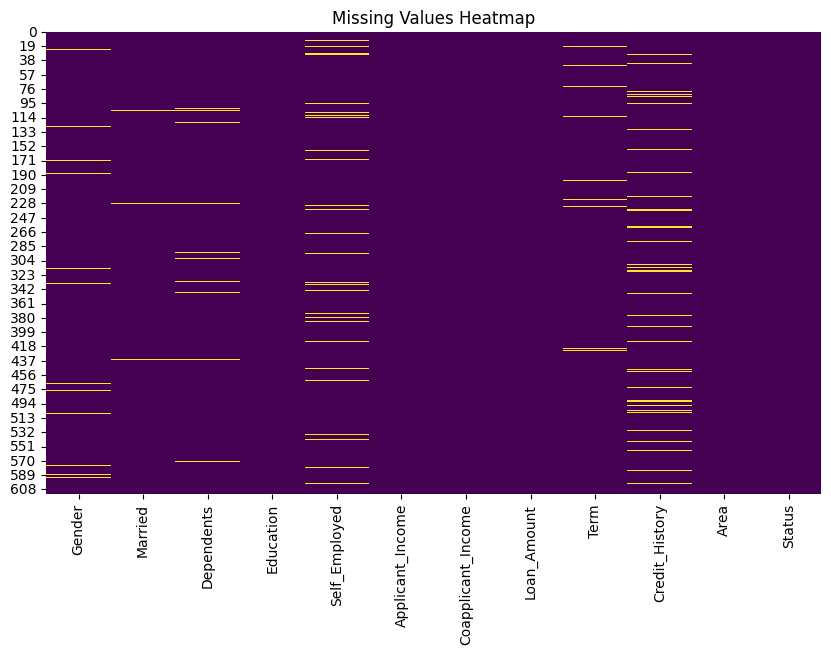

In [12]:
# Heatmap of missing values
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.show()

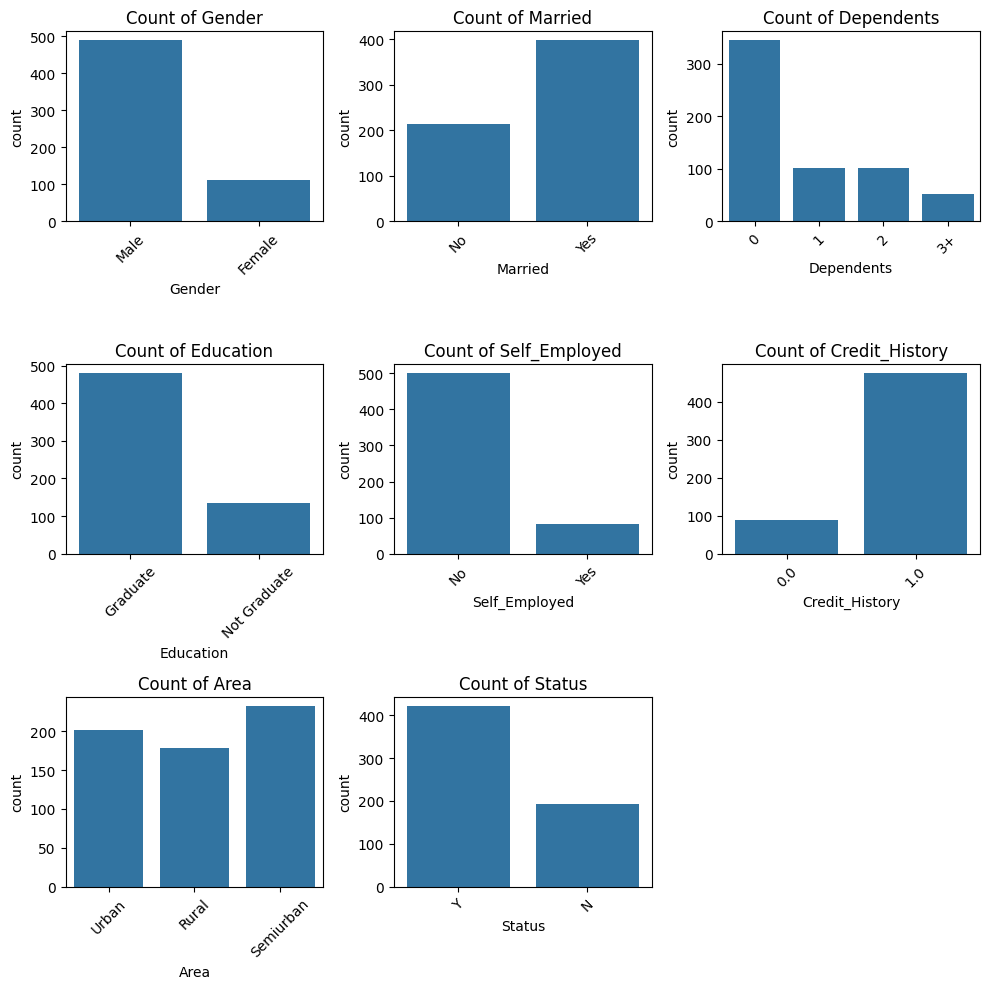

In [15]:
categorical_cols = ['Gender', 'Married', 'Dependents', 'Education',
                    'Self_Employed', 'Credit_History', 'Area', 'Status']

plt.figure(figsize=(10,10))
for i, col in enumerate(categorical_cols):
    plt.subplot(3,3,i+1)
    sns.countplot(x=col, data=df)
    plt.title(f"Count of {col}")
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

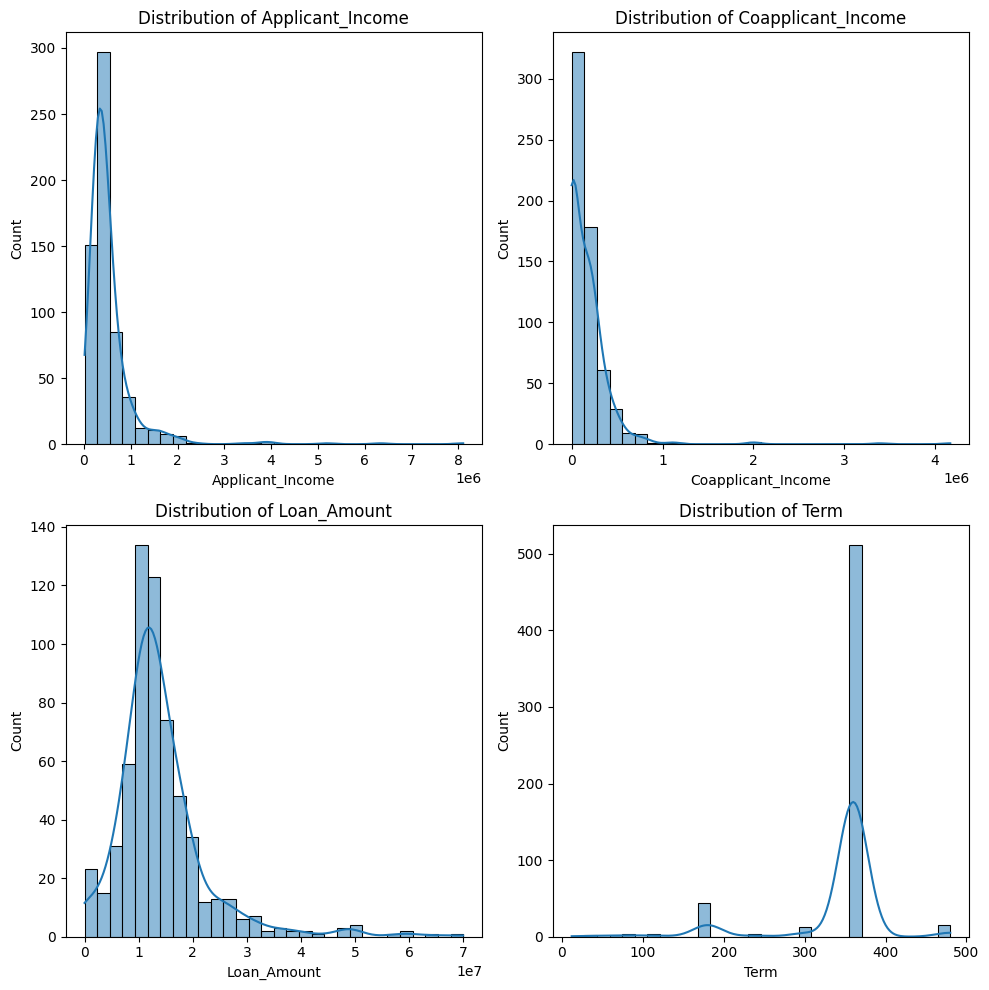

In [16]:
numerical_cols = ['Applicant_Income', 'Coapplicant_Income', 'Loan_Amount', 'Term']

plt.figure(figsize=(10,10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2,2,i+1)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

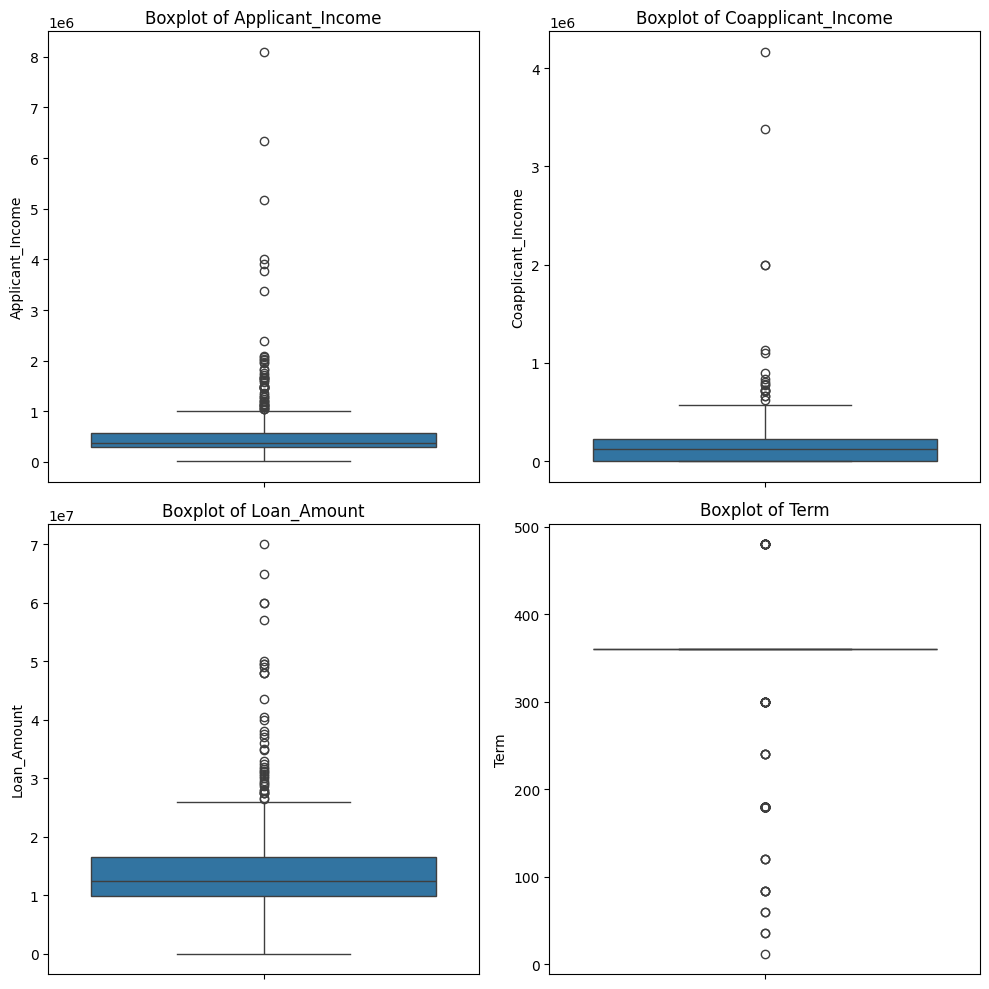

In [17]:
plt.figure(figsize=(10,10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2,2,i+1)
    sns.boxplot(y=df[col])
    plt.title(f"Boxplot of {col}")
plt.tight_layout()
plt.show()

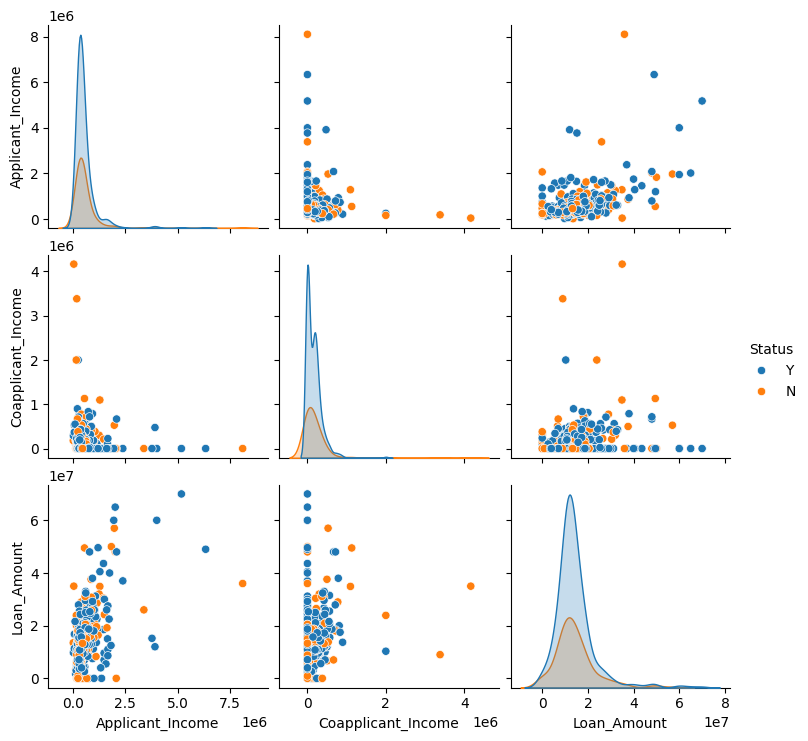

In [ ]:
sns.pairplot(df, hue='Status', vars=['Applicant_Income', 'Coapplicant_Income', 'Loan_Amount'])
plt.show()

# Data Cleaning

In [ ]:
# convert data type
df['Dependents'] = df['Dependents'].fillna(df['Dependents'].mode()[0])
df['Dependents'] = df['Dependents'].replace('3+',3)
df['Dependents'] = df['Dependents'].astype(int)

Justification

The Dependents column was cleaned by first replacing the value “3+” with 3 to convert categorical-like data into numerical format. Missing values were filled using the mode because dependents is a discrete variable and the most frequent value is the most appropriate replacement. Finally, the column was converted to integer type to ensure compatibility with machine learning algorithms.

In [ ]:
df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)

df['Married'].fillna(df['Married'].mode()[0], inplace=True)

Justification

Missing values in Gender and Married columns were filled using the mode because these are categorical variables. Using the mode preserves the original data distribution and avoids introducing bias that could occur if other statistical measures were used. This approach helps maintain data consistency during analysis.

In [ ]:
df = df.dropna(subset=['Term', 'Credit_History'])

print(df[['Term', 'Credit_History']].isnull().sum())

Term              0
Credit_History    0
dtype: int64


In [ ]:
# Remove Rows with Null in Dependents or Self_Employed
df = df.dropna(subset=['Dependents', 'Self_Employed'])

# verify
print(df[['Dependents', 'Self_Employed']].isnull().sum())

Dependents       0
Self_Employed    0
dtype: int64


Justification

Rows with missing values in Dependents and Self_Employed were removed because these attributes are important for understanding loan eligibility and borrower profile. Keeping null values could lead to inaccurate analysis, so removing them ensures data integrity.

In [ ]:
# Remove Rows Where Loan Amount is 0
df.drop(df[df['Loan_Amount'] == 0].index, inplace=True)

Justification

Rows with a Loan_Amount value of 0 were removed from the dataset because a loan amount of zero does not represent a valid loan transaction. Since the objective of this analysis is to study loan approvals and financial behavior related to loan amounts, records with zero loan value were considered irrelevant and excluded from the dataset to maintain data quality and analytical accuracy.

In [ ]:
# Check missing rows
df.isnull().sum()

Gender                0
Married               0
Dependents            0
Education             0
Self_Employed         0
Applicant_Income      0
Coapplicant_Income    0
Loan_Amount           0
Term                  0
Credit_History        0
Area                  0
Status                0
dtype: int64

In [ ]:
df.shape

(505, 12)

In [ ]:
df.head()

,Gender,Married,Dependents,Education,Self_Employed,Applicant_Income,Coapplicant_Income,Loan_Amount,Term,Credit_History,Area,Status
0,Male,No,0,Graduate,No,584900,0.0,15000000,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,458300,150800.0,12800000,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,300000,0.0,6600000,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,258300,235800.0,12000000,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,600000,0.0,14100000,360.0,1.0,Urban,Y


# Exploratory Data Analysis

## 1. Descriptive Statistics

In [ ]:
df.describe()

,Dependents,Applicant_Income,Coapplicant_Income,Loan_Amount,Term,Credit_History
count,505.000000,5.050000e+02,5.050000e+02,5.050000e+02,505.000000,505.000000
mean,0.766337,5.468410e+05,1.555540e+05,1.460851e+07,342.582178,0.845545
std,1.023947,5.996618e+05,2.571836e+05,8.342642e+06,65.095669,0.361743
min,0.000000,1.500000e+04,0.000000e+00,9.000000e+05,36.000000,0.000000
25%,0.000000,2.917000e+05,0.000000e+00,1.000000e+07,360.000000,1.000000
50%,0.000000,3.859000e+05,1.041000e+05,1.280000e+07,360.000000,1.000000
75%,2.000000,5.829000e+05,2.232000e+05,1.700000e+07,360.000000,1.000000
max,3.000000,8.100000e+06,3.383700e+06,7.000000e+07,480.000000,1.000000


Justification

Descriptive statistics were performed to summarize the central tendency, dispersion, and distribution characteristics of numerical variables in the dataset. Measures such as mean, median, standard deviation, and percentile values help understand the financial behavior of loan applicants. This analysis provides initial insights into income levels, loan amounts, and repayment terms.

## 2. Sampling Estimation

In [ ]:
sample_df = df.sample(frac=0.3, random_state=42)

sample_df.describe()

,Dependents,Applicant_Income,Coapplicant_Income,Loan_Amount,Term,Credit_History
count,152.000000,1.520000e+02,1.520000e+02,1.520000e+02,152.000000,152.000000
mean,0.743421,6.107987e+05,1.638303e+05,1.528092e+07,338.921053,0.855263
std,1.013137,8.219553e+05,3.240149e+05,9.749177e+06,64.850263,0.352998
min,0.000000,6.450000e+04,0.000000e+00,2.500000e+06,36.000000,0.000000
25%,0.000000,3.024750e+05,0.000000e+00,1.000000e+07,360.000000,1.000000
50%,0.000000,4.166500e+05,1.016000e+05,1.300000e+07,360.000000,1.000000
75%,1.000000,6.224500e+05,2.127750e+05,1.850000e+07,360.000000,1.000000
max,3.000000,8.100000e+06,3.383700e+06,7.000000e+07,480.000000,1.000000


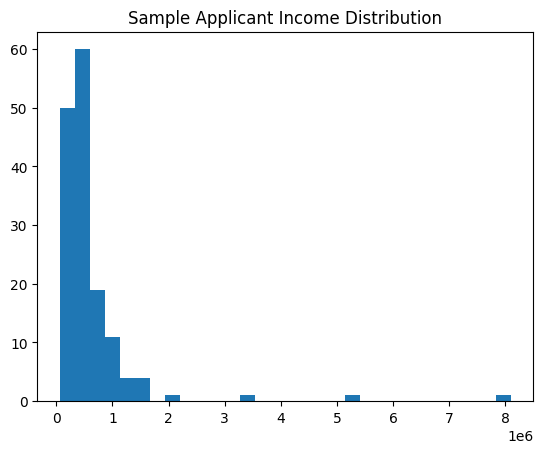

In [ ]:
plt.hist(sample_df['Applicant_Income'], bins=30)
plt.title("Sample Applicant Income Distribution")
plt.show()

Justification

Sampling estimation was performed by selecting 30% of the dataset randomly. Sampling helps reduce computational complexity while maintaining statistical representativeness. This approach allows approximate population inference without analyzing the entire dataset.

## 3. Hypothesis Testing

Business Hypothesis:

H0: Applicant income does not influence loan approval

H1: Applicant income influences loan approval

A t-test is performed to determine whether there is a significant difference between income levels of approved and rejected applicants.

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_cols = ['Gender','Married','Education','Self_Employed','Area','Status']

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 505 entries, 0 to 613
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Gender              505 non-null    int64  
 1   Married             505 non-null    int64  
 2   Dependents          505 non-null    int64  
 3   Education           505 non-null    int64  
 4   Self_Employed       505 non-null    int64  
 5   Applicant_Income    505 non-null    int64  
 6   Coapplicant_Income  505 non-null    float64
 7   Loan_Amount         505 non-null    int64  
 8   Term                505 non-null    float64
 9   Credit_History      505 non-null    float64
 10  Area                505 non-null    int64  
 11  Status              505 non-null    int64  
dtypes: float64(3), int64(9)
memory usage: 51.3 KB


In [ ]:
from scipy import stats
approved_income = df[df['Status']==1]['Applicant_Income']
rejected_income = df[df['Status']==0]['Applicant_Income']

t_stat, p_value = stats.ttest_ind(approved_income, rejected_income)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: -0.3004818627079273
P-value: 0.7639337800285274


Justification:

The result shows t = -0.300 and p = 0.769. Since the p-value is greater than 0.05, the null hypothesis cannot be rejected. This means applicant income does not have a significant influence on loan approval in this dataset.

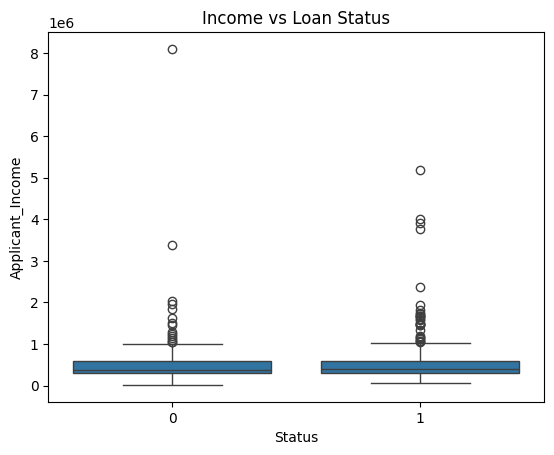

In [ ]:
sns.boxplot(x='Status', y='Applicant_Income', data=df)
plt.title("Income vs Loan Status")
plt.show()

## 4. Distribution Visualization

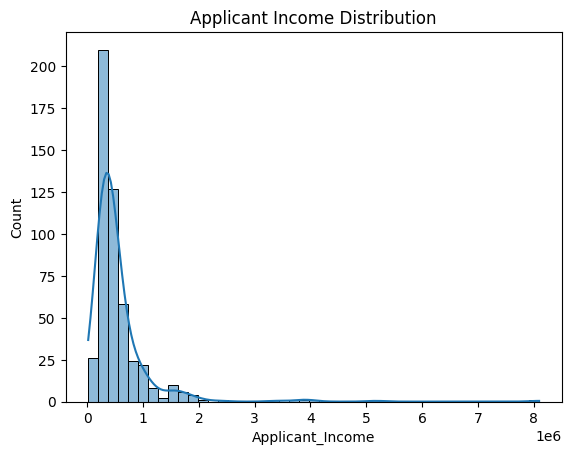

In [ ]:
# Applicant Income Distribution
sns.histplot(df['Applicant_Income'], kde=True)
plt.title("Applicant Income Distribution")
plt.show()

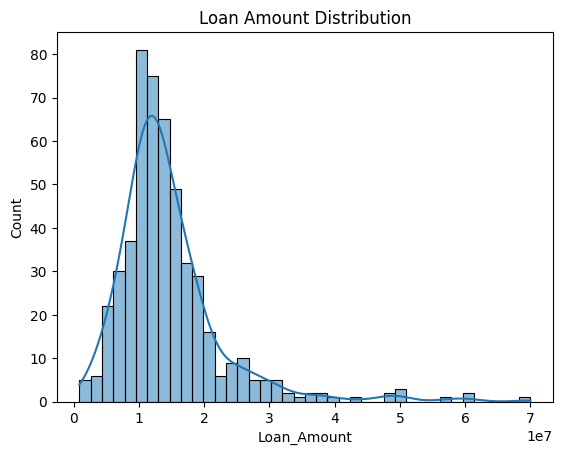

In [ ]:
# Loan Amount Distribution
sns.histplot(df['Loan_Amount'], kde=True)
plt.title("Loan Amount Distribution")
plt.show()

Justification

Distribution plots were generated to examine the spread and shape of numerical variables. The analysis helps identify skewness, concentration of values, and potential outliers in income and loan amount variables.

## 5. Regression Plot

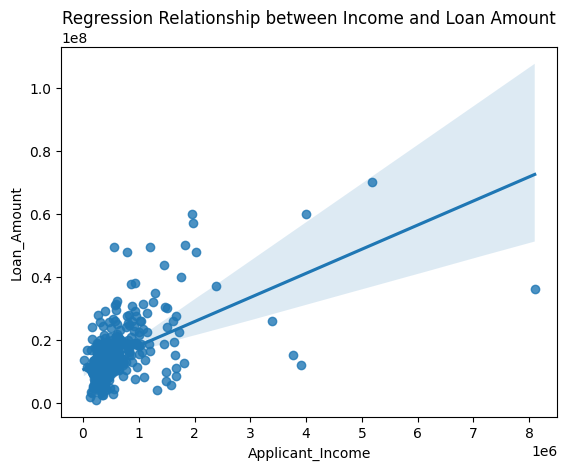

In [ ]:
sns.regplot(x='Applicant_Income', y='Loan_Amount', data=df)
plt.title("Regression Relationship between Income and Loan Amount")
plt.show()

Justification

Regression plots were used to visualize the linear relationship between applicant income and loan amount. This helps determine whether higher income levels are associated with larger loan requests, which is important for financial risk assessment.

# Model Building — Logistic Regression

In [ ]:
# Define Features and Target Variable
X = df.drop('Status', axis=1)
y = df['Status']

# Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Logistic Regression Model
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Make Predictions
y_pred = model.predict(X_test)

Justification for Assignment Report

Logistic Regression was selected as the predictive modeling technique because the business problem involves binary classification, where the objective is to determine whether a loan application will be approved or rejected. The model learns the relationship between applicant financial characteristics and loan approval status. Model performance was evaluated using accuracy, precision, recall, and F1-score metrics.

# 4. Data Visualization in Python

## Loan Approval Distribution

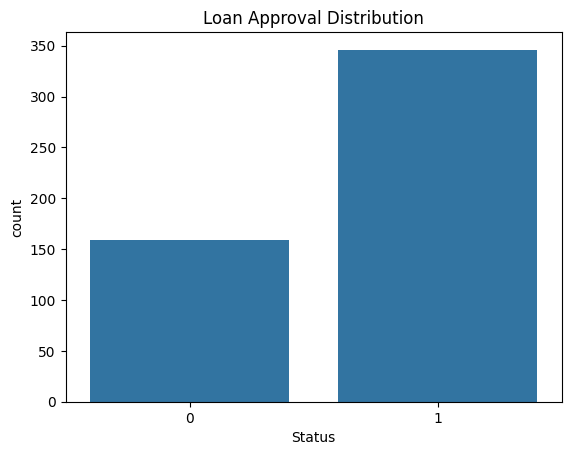

In [ ]:
sns.countplot(x='Status', data=df)
plt.title("Loan Approval Distribution")
plt.show()

This visualization helps understand the proportion of loan approvals and rejections in the dataset.

## Applicant Income Distribution

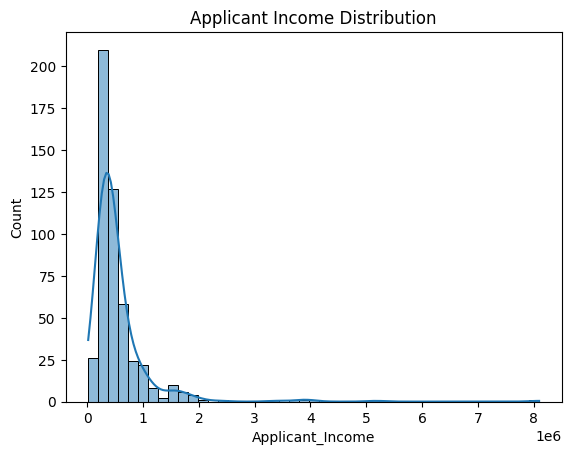

In [ ]:
sns.histplot(df['Applicant_Income'], kde=True)
plt.title("Applicant Income Distribution")
plt.show()

Income distribution analysis helps understand financial capability of loan applicants.

## Loan Amount Distribution

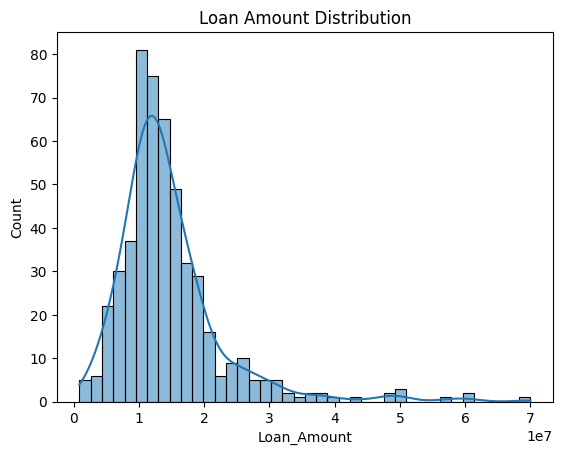

In [ ]:
sns.histplot(df['Loan_Amount'], kde=True)
plt.title("Loan Amount Distribution")
plt.show()

## Credit History vs Loan Status

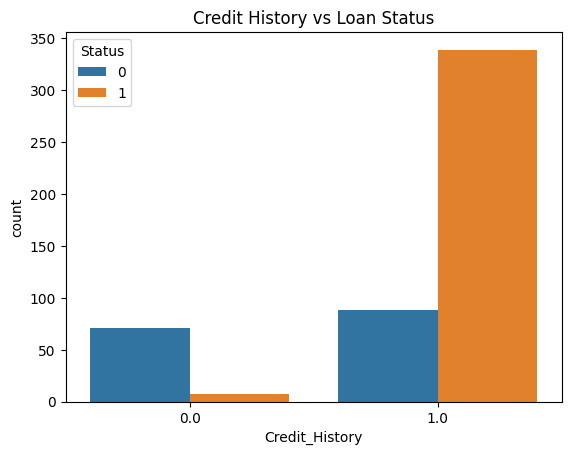

In [ ]:
sns.countplot(x='Credit_History', hue='Status', data=df)
plt.title("Credit History vs Loan Status")
plt.show()

Credit history is one of the strongest predictors of loan approval decisions.

## Area vs Loan Status

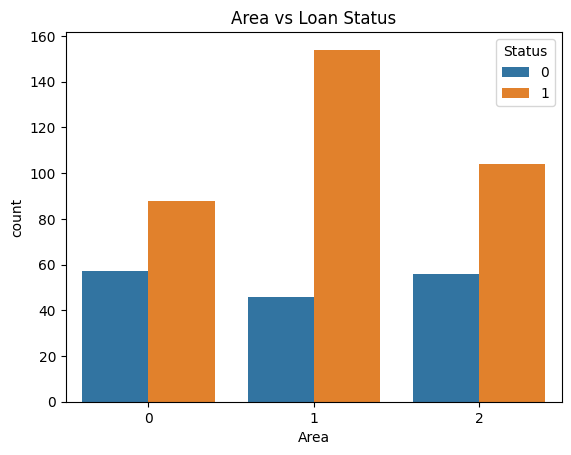

In [ ]:
sns.countplot(x='Area', hue='Status', data=df)
plt.title("Area vs Loan Status")
plt.show()

## Income vs Loan Amount Regression Plot

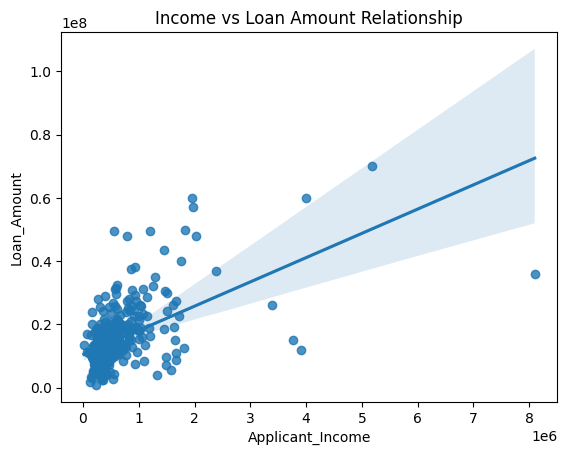

In [ ]:
sns.regplot(x='Applicant_Income', y='Loan_Amount', data=df)
plt.title("Income vs Loan Amount Relationship")
plt.show()

# Model Evaluation — Loan Prediction Model

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

## Calculate Model Accuracy

In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.8316831683168316


## Precision Score

In [ ]:
precision = precision_score(y_test, y_pred, zero_division=1)

print("Precision:", precision)

Precision: 0.8160919540229885


## Recall Score

In [ ]:
recall = recall_score(y_test, y_pred, zero_division=1)

print("Recall:", recall)

Recall: 0.9861111111111112


## F1 Score

In [ ]:
f1 = f1_score(y_test, y_pred, zero_division=1)

print("F1 Score:", f1)

F1 Score: 0.8930817610062893


## Confusion Matrix Visualization

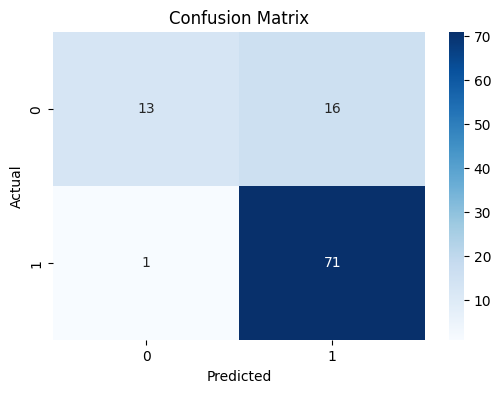

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Classification Report

In [ ]:
print(classification_report(y_test, y_pred, zero_division=1))

              precision    recall  f1-score   support

           0       0.93      0.45      0.60        29
           1       0.82      0.99      0.89        72

    accuracy                           0.83       101
   macro avg       0.87      0.72      0.75       101
weighted avg       0.85      0.83      0.81       101



Model performance was evaluated using multiple classification metrics including accuracy, precision, recall, and F1-score. Accuracy measures the overall correctness of predictions, while precision evaluates the proportion of correctly predicted positive cases. Recall measures the model’s ability to identify actual positive cases, and the F1-score provides a balanced measure between precision and recall.

The confusion matrix was also visualized to better understand the model prediction distribution.

# Export Clean Dataset

In [ ]:
df['Gender'] = df['Gender'].map({1:'Male', 0:'Female'})
df['Status'] = df['Status'].map({1:'Y', 0:'N'})
df['Education'] = df['Education'].map({1:'Graduate', 0:'Not Graduate'})
df['Self_Employed'] = df['Self_Employed'].map({1:'Yes', 0:'No'})
df['Area'] = df['Area'].map({2:'Urban', 1:'Rural', 0:'Semiurban'})
df['Married'] = df['Married'].map({1:'Yes', 0:'No'})

In [ ]:
df.head()

,Gender,Married,Dependents,Education,Self_Employed,Applicant_Income,Coapplicant_Income,Loan_Amount,Term,Credit_History,Area,Status
0,Male,No,0,Not Graduate,No,584900,0.0,15000000,360.0,1.0,Urban,Y
1,Male,Yes,1,Not Graduate,No,458300,150800.0,12800000,360.0,1.0,Semiurban,N
2,Male,Yes,0,Not Graduate,Yes,300000,0.0,6600000,360.0,1.0,Urban,Y
3,Male,Yes,0,Graduate,No,258300,235800.0,12000000,360.0,1.0,Urban,Y
4,Male,No,0,Not Graduate,No,600000,0.0,14100000,360.0,1.0,Urban,Y


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 505 entries, 0 to 613
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Gender              505 non-null    object 
 1   Married             505 non-null    object 
 2   Dependents          505 non-null    int64  
 3   Education           505 non-null    object 
 4   Self_Employed       505 non-null    object 
 5   Applicant_Income    505 non-null    int64  
 6   Coapplicant_Income  505 non-null    float64
 7   Loan_Amount         505 non-null    int64  
 8   Term                505 non-null    float64
 9   Credit_History      505 non-null    float64
 10  Area                505 non-null    object 
 11  Status              505 non-null    object 
dtypes: float64(3), int64(3), object(6)
memory usage: 51.3+ KB


In [ ]:
df.to_csv("cleaned_loan_dataset.csv", index=False, encoding='utf-8')